In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
#ratio_smooth = np.divide(y1_smooth, y2_smooth, out=np.zeros_like(y1_smooth), where=y2_smooth!=0)#

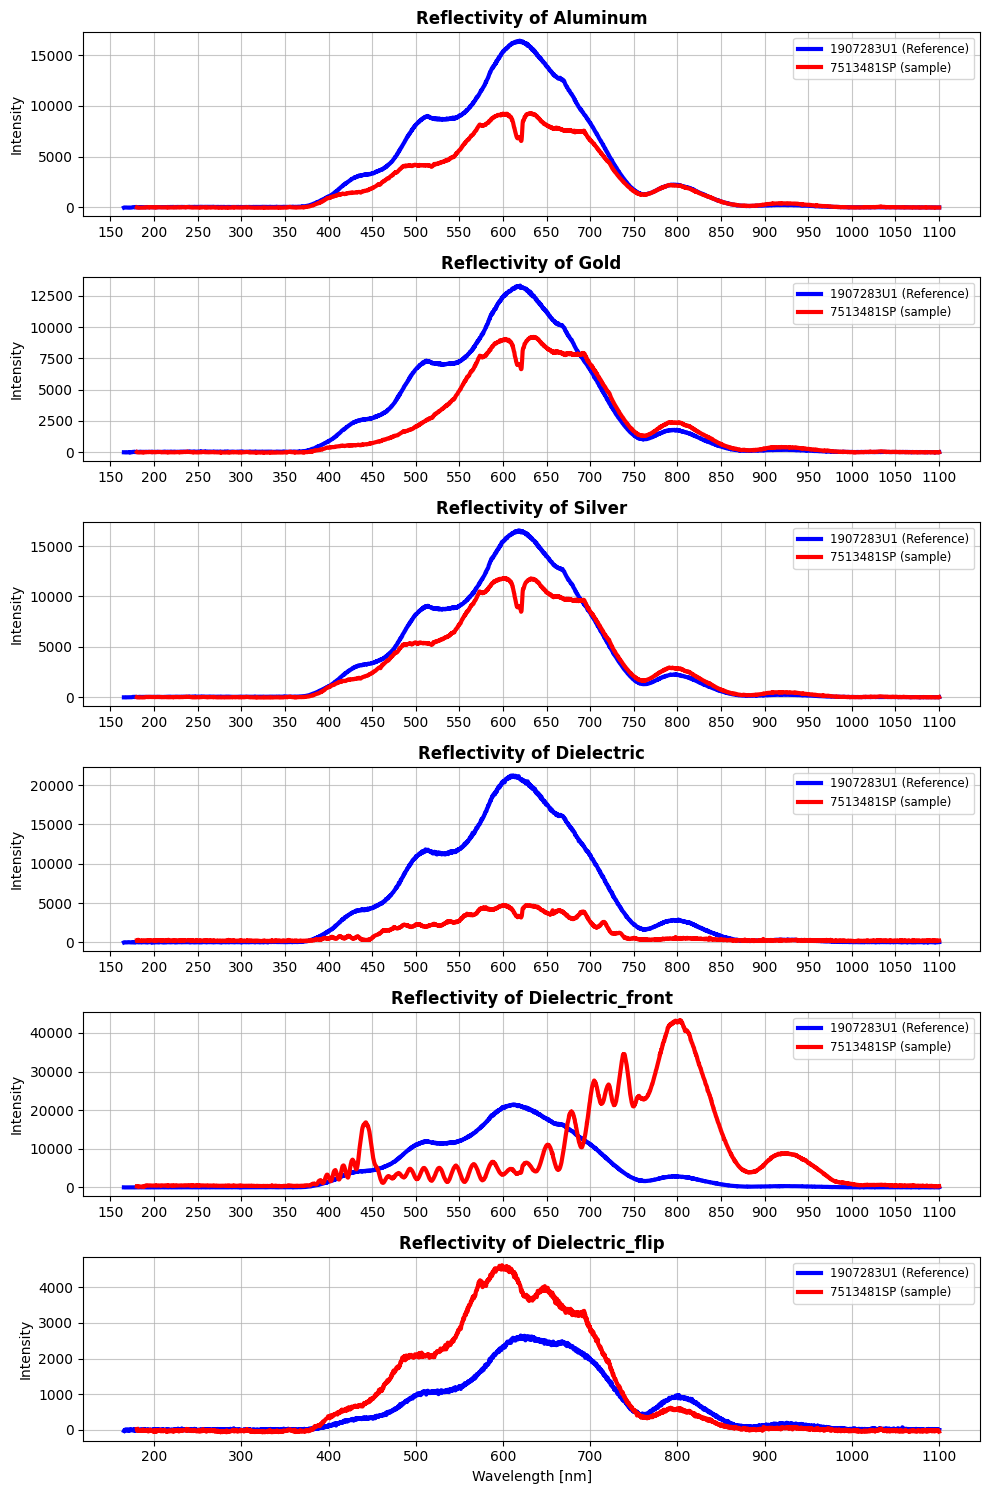

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# File list and labels
files = ['1Aluminum.csv', '2Gold_Spectrum.csv', 'Silver.csv', 'Dielectric.csv', 'Dielectric_front.csv', 'Dielectric_flip.csv']
labels = ['Aluminum', 'Gold', 'Silver', 'Dielectric', 'Dielectric_front','Dielectric_flip']

# Set up the figure with 4 stacked subplots
fig, axes = plt.subplots(nrows=len(files), ncols=1, figsize=(10, 16))

for i, file in enumerate(files):
    # Load data: skipping the first metadata row, using ; and , for decimals
    df = pd.read_csv(file, sep=';', skiprows=1, decimal=',')
    
    # --- Channel 1 (First two columns) ---
    # We use dropna() because Channel 1 and 2 often have different row counts
    w1 = df.iloc[:, 0].dropna().astype(float)
    i1 = df.iloc[:, 1].dropna().astype(float)
    
    # --- Channel 2 (Third and fourth columns) ---
    w2 = df.iloc[:, 2].dropna().astype(float)
    i2 = df.iloc[:, 3].dropna().astype(float)
    
    # Plot both channels on the current subplot
    axes[i].plot(w1, i1, label='1907283U1 (Reference)', color='b',lw=3)
    axes[i].plot(w2, i2, label='7513481SP (sample)', color='r', lw=3)
    axes[i].xaxis.set_major_locator(ticker.MultipleLocator(50))
    
    # Formatting each subplot
    axes[i].set_title(f'Reflectivity of {labels[i]}', fontweight='bold')
    axes[i].set_ylabel('Intensity')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].grid(True, alpha=0.7)

# Final global formatting
axes[-1].set_xlabel('Wavelength [nm]')
#plt.suptitle('Spectroscopic Data: Dual-Channel Vertical Stack',  fontsize=16)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(100))
plt.legend
plt.savefig('stack0.png')
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Leave space for the super-title
plt.show()

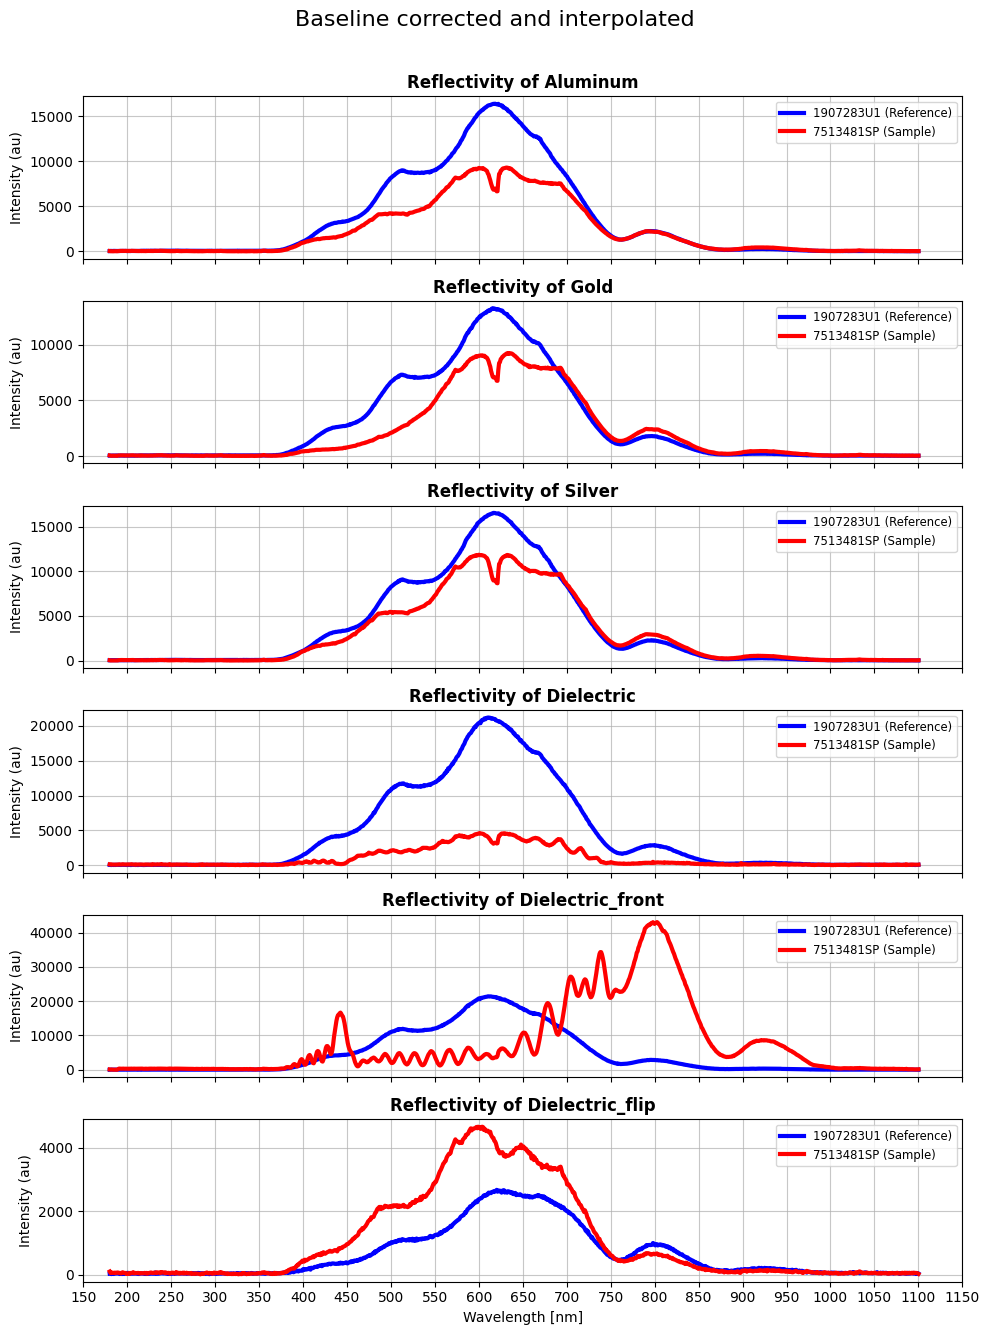

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# File list and names for legends
# Note: Ensure all files exist in your directory
files = ['1Aluminum.csv', '2Gold_Spectrum.csv', 'Silver.csv', 'Dielectric.csv', 'Dielectric_front.csv', 'Dielectric_flip.csv']
labels = ['Aluminum', 'Gold', 'Silver', 'Dielectric', 'Dielectric_front','Dielectric_flip']

# Setting up subplots: one row for each file
fig, axes = plt.subplots(nrows=len(files), ncols=1, sharex=True, figsize=(10, 14))

for i, file in enumerate(files):
    # Load data: skipping metadata, using ; separator and , for decimals
    df = pd.read_csv(file, sep=';', skiprows=1, decimal=',')
    
    # --- Extract Channel 1 ---
    # We use .values to work with NumPy arrays for interpolation
    w1 = df.iloc[:, 0].dropna().astype(float).values
    i1 = df.iloc[:, 1].dropna().astype(float).values
    
    # --- Extract Channel 2 ---
    w2 = df.iloc[:, 2].dropna().astype(float).values
    i2 = df.iloc[:, 3].dropna().astype(float).values
    
    # --- 1. Baseline Correction (Subtracting the minimum) ---
    i1 = i1 - np.min(i1)
    i2 = i2 - np.min(i2)
    
    # --- 2. Interpolation onto a common wavelength range ---
    # Find the bounds where BOTH sensors have data
    x_min = max(np.min(w1), np.min(w2))
    x_max = min(np.max(w1), np.max(w2))
    # Create 1000 common x-points between the overlapping range
    common_x = np.linspace(x_min, x_max, 1000)
    
    # Interpolate both intensities onto the common wavelength grid
    i1_interp = np.interp(common_x, w1, i1)
    i2_interp = np.interp(common_x, w2, i2)
    
    # --- Plot the processed data ---
    axes[i].plot(common_x, i1_interp, label='1907283U1 (Reference)', color='b', lw=3)
    axes[i].plot(common_x, i2_interp, label='7513481SP (Sample)', color='r', lw=3)
    
    # Formatting each subplot
    axes[i].set_title(f'Reflectivity of {labels[i]}',fontweight='bold')
    axes[i].set_ylabel('Intensity (au)')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].grid(True, alpha=0.7)
    
    # Set x-axis ticks to 50nm intervals as requested
    axes[i].xaxis.set_major_locator(ticker.MultipleLocator(50))

# Global Formatting
axes[-1].set_xlabel('Wavelength [nm]')
plt.suptitle('Baseline corrected and interpolated', fontsize=16)
plt.xlim(150, 1150) # Covering the full spectral range
plt.savefig('stack1')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# Aluminum

df1=pd.read_csv('channel_1.txt', sep='\t'); df2= pd.read_csv('channel_2.txt', sep='\t')
print(df1.head(3)); print(df2.head(3))

In [4]:
df_full = pd.read_csv('1Aluminum.csv', sep=';', decimal=',', skiprows=1)
df1 = df_full.iloc[:, [0, 1]].dropna()
df2 = df_full.iloc[:, [2, 3]].dropna()

In [5]:
df1,df2

(      Wavelength [nm]  Intensity
 0            165.3892 -11.820007
 1            165.6764   0.650570
 2            165.9636  -2.198996
 3            166.2507   1.619158
 4            166.5379  -0.852688
 ...               ...        ...
 3251        1099.0479  -0.685485
 3252        1099.3351  -2.093618
 3253        1099.6223  -2.562877
 3254        1099.9095   5.770115
 3255        1100.1967   4.250000
 
 [3256 rows x 2 columns],
       Wavelength [nm].1  intensity
 0              180.2263   5.899994
 1              180.5152  -6.349728
 2              180.8041  -5.782222
 3              181.0930  -9.242954
 4              181.3819 -21.519651
 ...                 ...        ...
 3180          1098.9085   1.680449
 3181          1099.1974  -5.267257
 3182          1099.4863  -1.603709
 3183          1099.7752  -2.978204
 3184          1100.0641   0.869995
 
 [3185 rows x 2 columns])

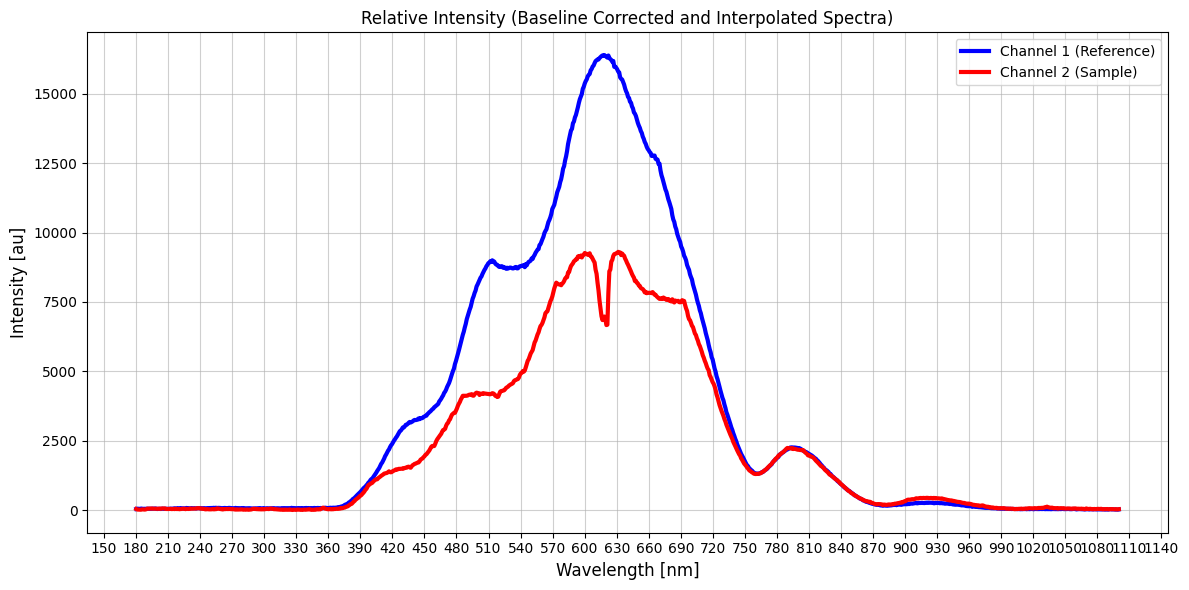

In [6]:
# 1. Baseline Correction (Subtracting the minimum)  #zero shifting
df1.iloc[:, 1] -= df1.iloc[:, 1].min()
df2.iloc[:, 1] -= df2.iloc[:, 1].min()

# 2. Interpolation onto a common wavelength range
x_min = max(df1.iloc[0, 0], df2.iloc[0, 0])
x_max = min(df1.iloc[-1, 0], df2.iloc[-1, 0])
common_x = np.linspace(x_min, x_max, 1000)

df1_interp = np.interp(common_x, df1.iloc[:, 0], df1.iloc[:, 1])
df2_interp = np.interp(common_x, df2.iloc[:, 0], df2.iloc[:, 1])

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.plot(common_x, df1_interp, 'b', lw=3, label='Channel 1 (Reference)')
plt.plot(common_x, df2_interp, 'r', lw=3, label='Channel 2 (Sample)')

# Axis formatting: Set 50 nm steps
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(30))
plt.xlabel('Wavelength [nm]', fontsize=12)
plt.ylabel('Intensity [au]', fontsize=12)
plt.grid(True, alpha=0.6)
plt.legend()
#plt.xlim(620, 900)
plt.title('Relative Intensity (Baseline Corrected and Interpolated Spectra)')
plt.tight_layout()
#plt.savefig('AL1')
plt.show()

# 1. baseline
for df in [df1, df2]:
    df.iloc[:, 1] -= df.iloc[:, 1].min()

# 2. Interpolation onto a common wavelength range
x_min, x_max = max(df1.iloc[0, 0], df2.iloc[0, 0]), min(df1.iloc[-1, 0], df2.iloc[-1, 0])
common_x = np.linspace(x_min, x_max, 1000)
df1_i = np.interp(common_x, df1.iloc[:, 0], df1.iloc[:, 1])
df2_i = np.interp(common_x, df2.iloc[:, 0], df2.iloc[:, 1])

# 3. Main Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(common_x, df1_i, 'r', lw=2, label='Channel 1')
ax.plot(common_x, df2_i, 'b', lw=2, label='Channel 2')
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Intensity [au]')
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.grid(True, linestyle=':', alpha=0.9)
ax.legend(loc='upper left')

# 4. Inset (Corrected names: ax, df1_i, df2_i)
# Removed the redundant plt.axes call
ax_zoom = inset_axes(ax, width="30%", height="30%", loc='upper right', borderpad=2)
ax_zoom.plot(common_x, df1_i, 'r.', lw=3)
ax_zoom.plot(common_x, df2_i, 'b.', lw=3)

# Define zoom range 
z_start, z_end = 590, 610 
ax_zoom.set_xlim(z_start, z_end)
ax_zoom.grid(True, alpha=0.6)
plt.suptitle('Relative Intensity (Corrected Spectra)')
plt.show()

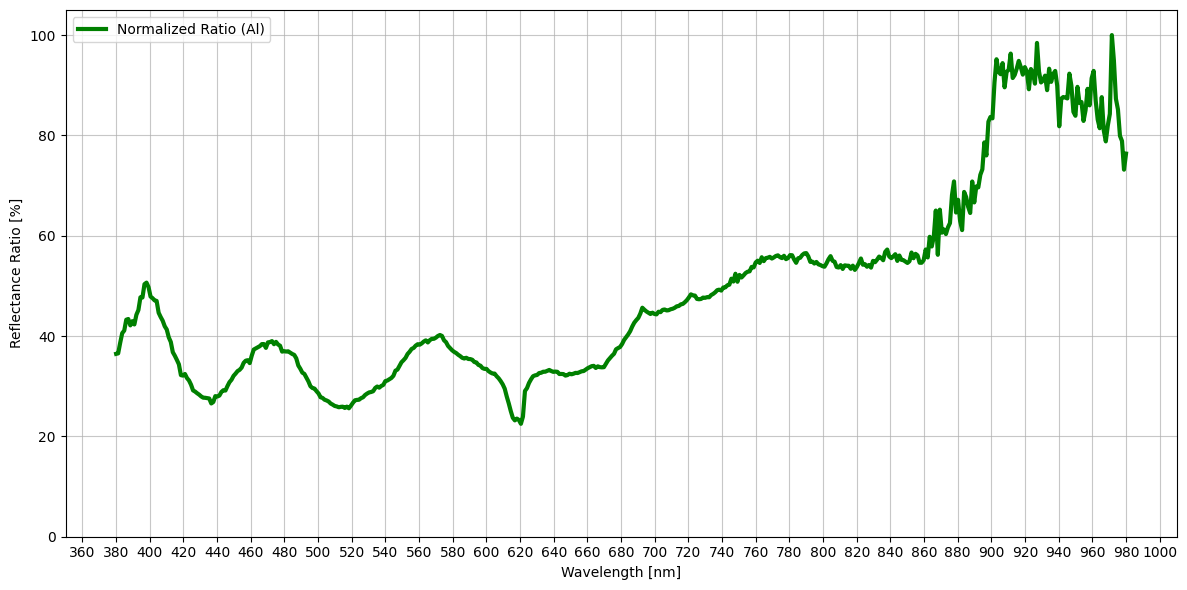

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
           380.0     0.6578            0.3645                 36.45
           405.0     0.8221            0.4556                 45.56
           430.0     0.4988            0.2764                 27.64
           455.0     0.6158            0.3413                 34.13
           480.0     0.6668            0.3696                 36.96
           505.0     0.4900            0.2715                 27.15
           530.0     0.5159            0.2859                 28.59
           555.0     0.6674            0.3699                 36.99
           580.0     0.6649            0.3685                 36.85
           605.0     0.5827            0.3229                 32.29
           630.0     0.5815            0.3223                 32.23
           655.0     0.5881            0.3259                 32.59
           680.0     0.6860            0.3802                 38.02
           705.0     0.8132            0.4507   

In [7]:
df = pd.read_csv('1Aluminum.csv', sep=';', decimal=',', skiprows=1)
df1 = df.iloc[:, [0, 1]].dropna() # Sample (Wavelength, Intensity)
df2 = df.iloc[:, [2, 3]].dropna() # Reference (Wavelength, Intensity)

# --- NEW BASELINE CORRECTION (Zero Shifting) ---
df1.iloc[:, 1] -= df1.iloc[:, 1].min()
df2.iloc[:, 1] -= df2.iloc[:, 1].min()

# 2. Interpolation onto common_x for Plotting
common_x = np.linspace(380, 980, 500)
y1_s = np.interp(common_x, df1.iloc[:, 0], df1.iloc[:, 1])
y2_s = np.interp(common_x, df2.iloc[:, 0], df2.iloc[:, 1])

# Calculate ratio (Sample / Reference) and scale to 100% MAX
# Added a small epsilon to avoid division by zero
ratio_s =  y2_s / y1_s
norm_plota = (ratio_s / ratio_s.max()) * 100

# 3. Table generation (30 nm steps)
steps_x =  np.linspace(380, 980, 25) # Rounds to neat steps
y1_t = np.interp(steps_x, df1.iloc[:, 0], df1.iloc[:, 1])
y2_t = np.interp(steps_x, df2.iloc[:, 0], df2.iloc[:, 1])

# Calculate Table Ratios scaled to the plot maximum
raw_r_t =  y2_t/y1_t 
norm_r_t = raw_r_t / ratio_s.max() 
norm_pct_t = norm_r_t * 100

# 4. Create Results Table
df_step = pd.DataFrame({
    'Wavelength [nm]': steps_x,
    'Raw Ratio': np.round(raw_r_t, 4),
    'Normalized Ratio': np.round(norm_r_t, 4),
    'Normalized Ratio [%]': np.round(norm_pct_t, 2)
})

# 5. Plotting
plt.figure(figsize=(12, 6))
plt.plot(common_x, norm_plota, lw=3, color='green', label='Normalized Ratio (Al)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.ylim(0, 105) 
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
#plt.title('Normalized Intensity Ratio (Baseline Corrected & Common Range)')
plt.grid(True, alpha=.7)
plt.legend()
plt.tight_layout()
plt.savefig('Al18r.png')
plt.show()

# Display the table
print(df_step.to_string(index=False))

# Gold (Au)

In [8]:
dfg = pd.read_csv('2Gold_Spectrum.csv', sep=';', decimal=',', skiprows=1)
df3 = dfg.iloc[:, [0, 1]].dropna()
df4 = dfg.iloc[:, [2, 3]].dropna()

In [9]:
df3

,Wavelength [nm],Intensity
0,165.3892,-8.320007
1,165.6764,-6.257464
2,165.9636,-10.053851
3,166.2507,-15.619530
4,166.5379,-8.406011
...,...,...
3251,1099.0479,-2.814917
3252,1099.3351,-8.322961
3253,1099.6223,-2.223819
3254,1099.9095,1.282934


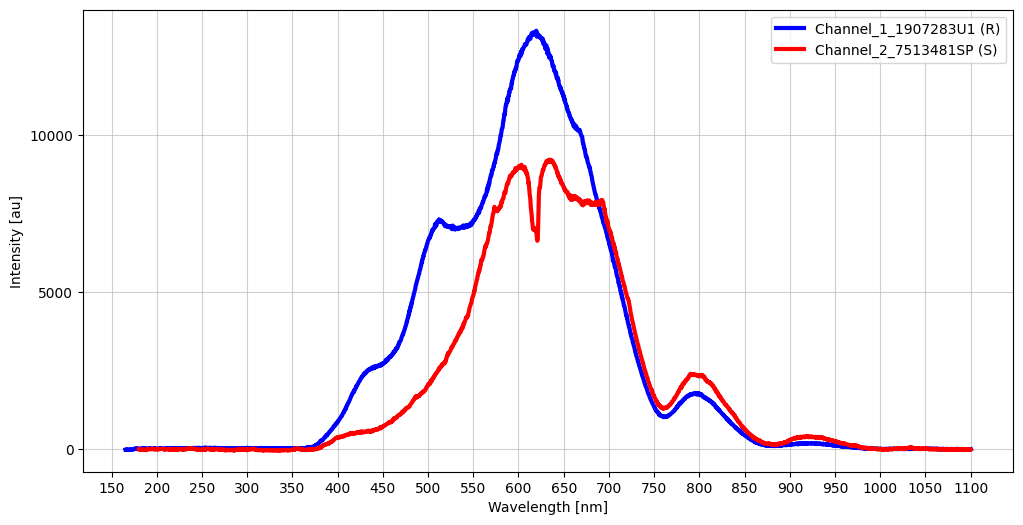

In [10]:
#Raw plotting
plt.figure( figsize=(12, 6))   #plt.figure(figsize=(12, 6), dpi=150, facecolor='#f0f0f0', edgecolor='black', linewidth=1,layout='tight')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5000))
plt.plot(df3.iloc[:,0], df3.iloc[:,1], 'b', lw=3,  label='Channel_1_1907283U1 (R)')
plt.plot(df4.iloc[:,0], df4.iloc[:,1], 'r', lw=3,  label='Channel_2_7513481SP (S)')
#plt.xlim(620, 630) #plt.ylim(40000, 500000)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
plt.grid(True, alpha=.6)
plt.legend()
#plt.title()
#plt.savefig('Alu1')
plt.show()

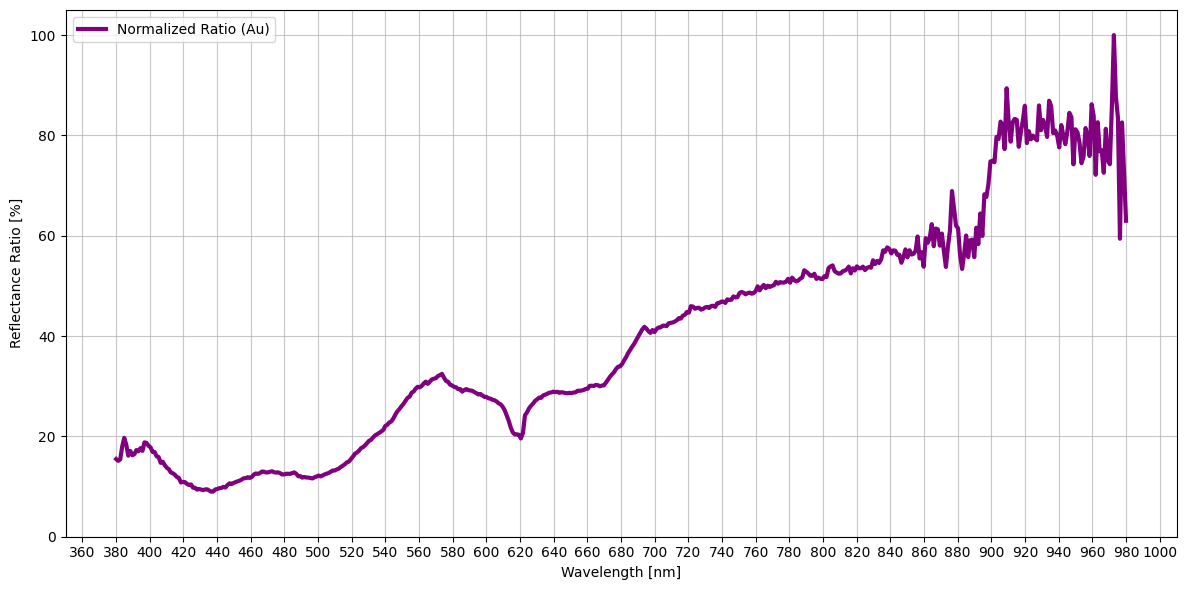

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
           380.0     0.4036            0.1549                 15.49
           405.0     0.4168            0.1599                 15.99
           430.0     0.2434            0.0934                  9.34
           455.0     0.2982            0.1144                 11.44
           480.0     0.3259            0.1250                 12.50
           505.0     0.3277            0.1257                 12.57
           530.0     0.4983            0.1912                 19.12
           555.0     0.7422            0.2848                 28.48
           580.0     0.7832            0.3005                 30.05
           605.0     0.7061            0.2709                 27.09
           630.0     0.7136            0.2738                 27.38
           655.0     0.7565            0.2902                 29.02
           680.0     0.8894            0.3412                 34.12
           705.0     1.0894            0.4180   

In [11]:

# 1. Data Loading
df = pd.read_csv('2Gold_Spectrum.csv', sep=';', decimal=',', skiprows=1)
df3 = df.iloc[:, [0, 1]].dropna() # Sample (Wavelength, Intensity)
df4 = df.iloc[:, [2, 3]].dropna() # Reference (Wavelength, Intensity)

# --- BASELINE CORRECTION (Zero Shifting) ---
df3.iloc[:, 1] -= df3.iloc[:, 1].min()
df4.iloc[:, 1] -= df4.iloc[:, 1].min()

# 2. Interpolation onto common_x for Plotting
common_x = np.linspace(380, 980, 500)
y1_s = np.interp(common_x, df3.iloc[:, 0], df3.iloc[:, 1])
y2_s = np.interp(common_x, df4.iloc[:, 0], df4.iloc[:, 1])

# Calculate ratio (Sample / Reference) and scale to 100% MAX
# Using df4/df3 as per your original logic
ratio_s =  y2_s/y1_s
norm_plotg = (ratio_s / ratio_s.max()) * 100

# 3. Table generation (Fixed steps)
steps_x = np.linspace(380, 980, 25) 
y1_t = np.interp(steps_x, df3.iloc[:, 0], df3.iloc[:, 1])
y2_t = np.interp(steps_x, df4.iloc[:, 0], df4.iloc[:, 1])

# Calculate Table Ratios scaled to the plot maximum
raw_r_t =  y2_t/y1_t
norm_r_t = raw_r_t / ratio_s.max() 
norm_pct_t = norm_r_t * 100

# 4. Create Results Table (with rounding applied to Wavelength)
df_step = pd.DataFrame({
    'Wavelength [nm]': np.round(steps_x, 2),
    'Raw Ratio': np.round(raw_r_t, 4),
    'Normalized Ratio': np.round(norm_r_t, 4),
    'Normalized Ratio [%]': np.round(norm_pct_t, 2)
})

# 5. Plotting
plt.figure(figsize=(12, 6))
# Using 'tab:green' for a clean, professional Matplotlib color
plt.plot(common_x, norm_plotg, lw=3, color='Purple', label='Normalized Ratio (Au)')

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.ylim(0, 105) 
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
#.title('Normalized Intensity Ratio (df3 vs df4 - Baseline Corrected)')
plt.grid(True, alpha=0.7)
plt.savefig('Au18r.png')
plt.legend()
plt.tight_layout()
plt.show()
# Display the table
print(df_step.to_string(index=False))

In [12]:
#df_step.to_csv('reflectance_ratio_Au.csv', index=False)

# Dielectric

In [13]:
dfd= pd.read_csv('Dielectric.csv', sep=';', decimal=',', skiprows=1)

df5 = dfd.iloc[:, [0, 1]].dropna()
df6 = dfd.iloc[:, [2, 3]].dropna()

In [14]:
dfd

,Wavelength [nm],Intensity,Wavelength [nm].1,intensity,Unnamed: 4
0,165.3892,-11.320007,180.2263,248.00000,NaN
1,165.6764,4.397109,180.5152,252.41525,NaN
2,165.9636,3.520583,180.8041,212.42808,NaN
3,166.2507,6.740937,181.0930,212.31787,NaN
4,166.5379,-13.474245,181.3819,228.83810,NaN
...,...,...,...,...,...
3251,1099.0479,23.734254,NaN,NaN,NaN
3252,1099.3351,26.841400,NaN,NaN,NaN
3253,1099.6223,17.708930,NaN,NaN,NaN
3254,1099.9095,25.124274,NaN,NaN,NaN


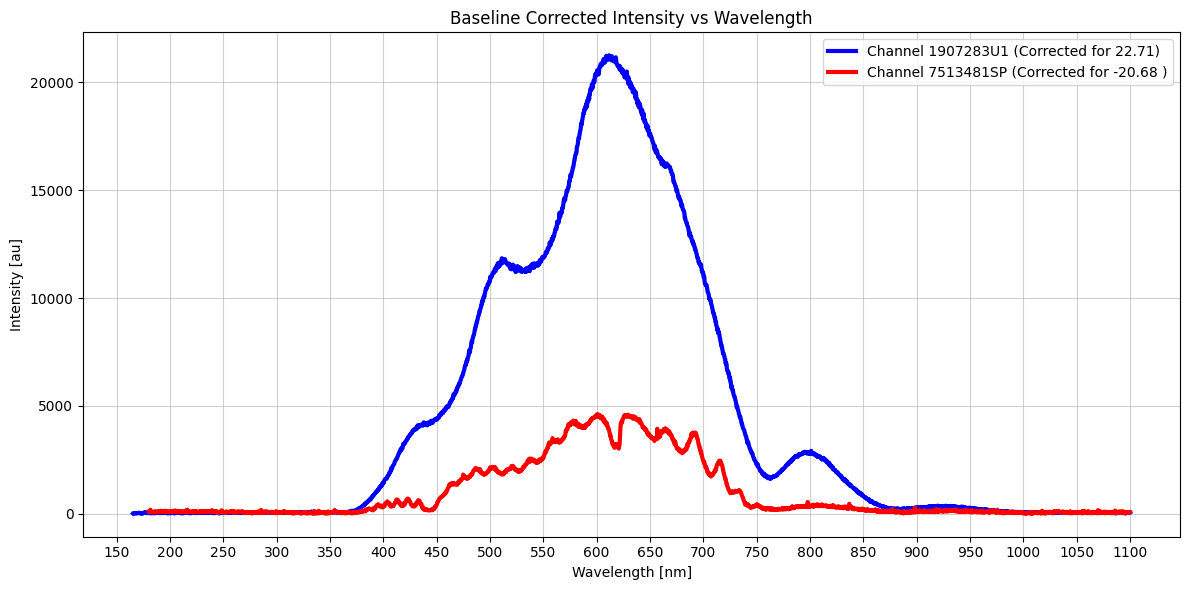

In [15]:
# Split into two dataframes
df5 = dfd.iloc[:, [0, 1]].dropna()
df6 = dfd.iloc[:, [2, 3]].dropna()

# Baseline correction: subtract the minimum value from the intensity column
df5.iloc[:, 1] -= df5.iloc[:, 1].min()
df6.iloc[:, 1] -= df6.iloc[:, 1].min()

# Plotting the corrected data
fig, ax = plt.subplots(figsize=(12, 6))
# Plotting the corrected data
#plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.plot(df5.iloc[:, 0], df5.iloc[:, 1], lw=3, color='blue', label='Channel 1907283U1 (Corrected for 22.71)')
plt.plot(df6.iloc[:, 0], df6.iloc[:, 1], lw=3, color='red', label='Channel 7513481SP (Corrected for -20.68 )')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
plt.title('Baseline Corrected Intensity vs Wavelength')
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

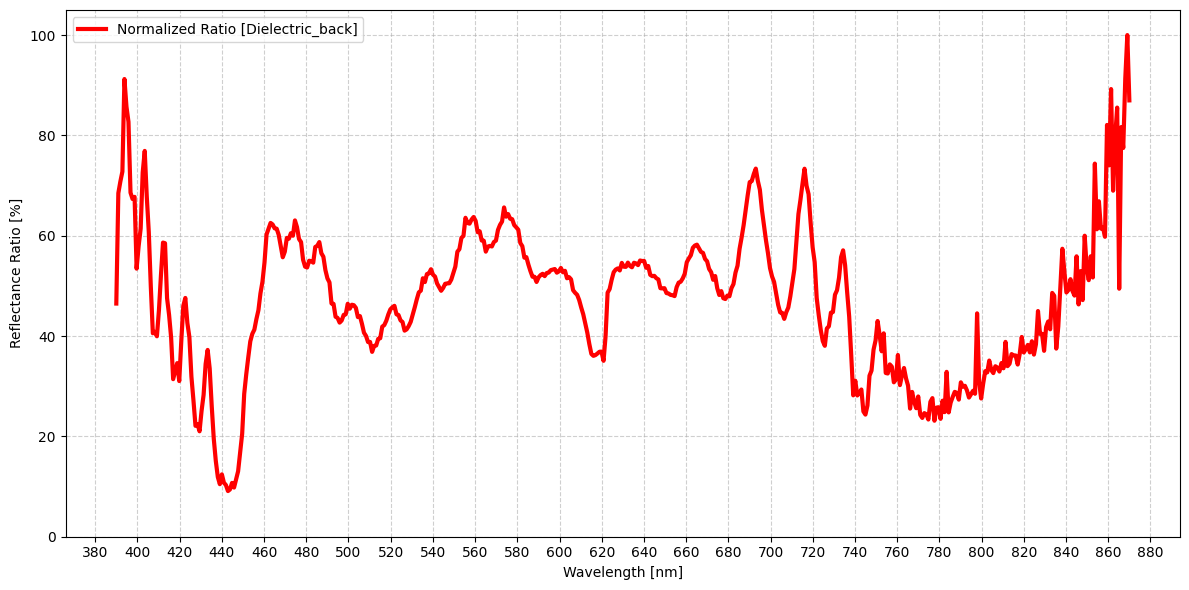

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
             390     0.1944            0.4648                 46.48
             410     0.1763            0.4216                 42.16
             430     0.0959            0.2292                 22.92
             450     0.0921            0.2201                 22.01
             470     0.2382            0.5694                 56.94
             490     0.2156            0.5153                 51.53
             510     0.1625            0.3885                 38.85
             530     0.1805            0.4315                 43.15
             550     0.2202            0.5265                 52.65
             570     0.2472            0.5909                 59.09
             590     0.2161            0.5166                 51.66
             610     0.1939            0.4636                 46.36
             630     0.2248            0.5374                 53.74
             650     0.2054            0.4910   

In [16]:
# Split into two dataframes and drop NaNs
df5 = dfd.iloc[:, [0, 1]].dropna().copy()
df6 = dfd.iloc[:, [2, 3]].dropna().copy()

# 1. Baseline Correction
df5.iloc[:, 1] -= df5.iloc[:, 1].min()
df6.iloc[:, 1] -= df6.iloc[:, 1].min()

# 2. Smooth Interpolation for the Plot (390-990nm, 600 points)
range_x = np.linspace(390, 870, 500)
y1_smooth = np.interp(range_x, df5.iloc[:, 0], df5.iloc[:, 1])
y2_smooth = np.interp(range_x, df6.iloc[:, 0], df6.iloc[:, 1])

# Calculate smooth ratios for plotting
# Added small epsilon 1e-9 to prevent division by zero if data is very noisy
ratio_smooth = y2_smooth / y1_smooth 
norm_ratio_pct_smoothDib = (ratio_smooth / ratio_smooth.max()) * 100

# 3. 30 nm steps for the Table (Corrected Lengths)
steps_x = np.arange(390, 960, 20) # +1 ensures 990 is included
y1_step = np.interp(steps_x, df5.iloc[:, 0], df5.iloc[:, 1])
y2_step = np.interp(steps_x, df6.iloc[:, 0], df6.iloc[:, 1])

# Calculate table ratios using the STEP arrays, not the SMOOTH arrays
raw_ratio_step = y2_step / y1_step
norm_ratio_step = raw_ratio_step / ratio_smooth.max() # Normalize relative to the plot max
norm_ratio_pct_step = norm_ratio_step * 100

# Create the table (All arrays are now the same length as steps_x)
df_step = pd.DataFrame({
    'Wavelength [nm]': np.round(steps_x, 2),
    'Raw Ratio': np.round(raw_ratio_step, 4),
    'Normalized Ratio': np.round(norm_ratio_step, 4),
    'Normalized Ratio [%]': np.round(norm_ratio_pct_step, 2)
})

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(range_x, norm_ratio_pct_smoothDib, lw=3, color='red', label='Normalized Ratio [Dielectric_back]')

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.ylim(0, 105) # Standardized for % reflectance
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
#plt.title('Normalized Intensity Ratio (Dielectric: Ch1 / Ch2)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save and Show
plt.savefig('Dielectric_b.png')
plt.show()

# Display the table
print(df_step.to_string(index=False))

# Dielectric_front

In [17]:
dfd1= pd.read_csv('Dielectric_front.csv', sep=';', decimal=',', skiprows=1)
df7 = dfd1.iloc[:, [0, 1]].dropna()
df8 = dfd1.iloc[:, [2, 3]].dropna()

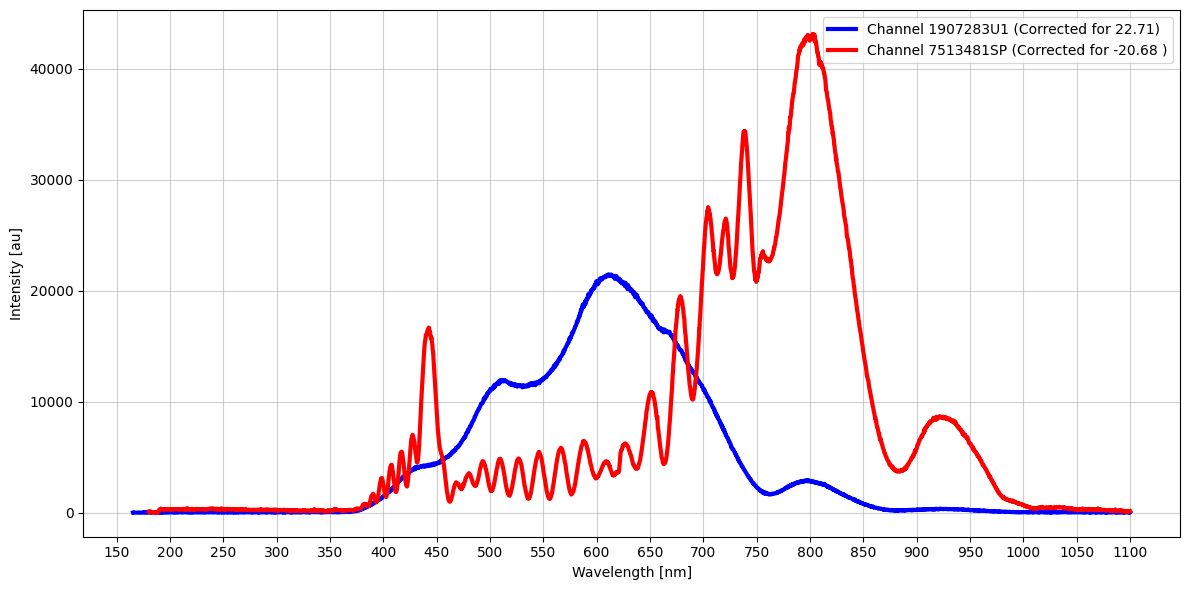

In [18]:
# Split into two dataframes
df7 = dfd1.iloc[:, [0, 1]].dropna()
df8 = dfd1.iloc[:, [2, 3]].dropna()

# Baseline correction: subtract the minimum value from the intensity column
df7.iloc[:, 1] -= df7.iloc[:, 1].min()
df8.iloc[:, 1] -= df8.iloc[:, 1].min()

# Plotting the corrected data
fig, ax = plt.subplots(figsize=(12, 6))
# Plotting the corrected data
#plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.plot(df7.iloc[:, 0], df7.iloc[:, 1], lw=3, color='blue', label='Channel 1907283U1 (Corrected for 22.71)')
plt.plot(df8.iloc[:, 0], df8.iloc[:, 1], lw=3, color='red', label='Channel 7513481SP (Corrected for -20.68 )')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
#plt.title('Baseline Corrected Intensity vs Wavelength')
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

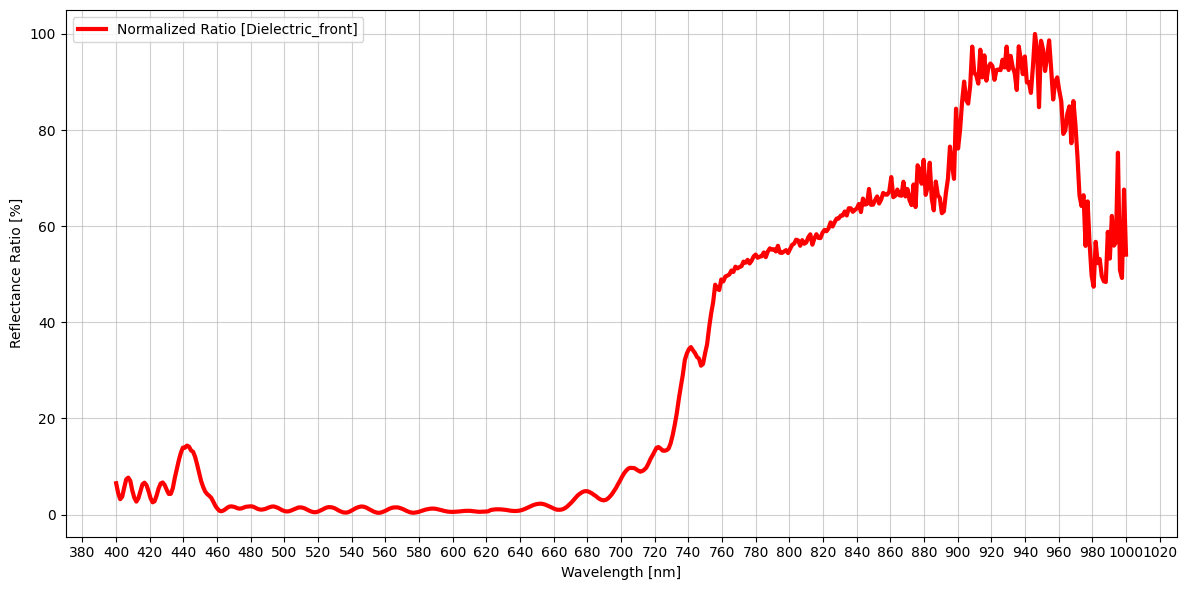

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
             390   2.018757          0.077274              7.727373
             420   1.062317          0.040663              4.066323
             450   2.082881          0.079728              7.972826
             480   0.472576          0.018089              1.808919
             510   0.407797          0.015610              1.560962
             540   0.236628          0.009058              0.905763
             570   0.319397          0.012226              1.222583
             600   0.153339          0.005869              0.586948
             630   0.281017          0.010757              1.075674
             660   0.345481          0.013224              1.322426
             690   0.803850          0.030770              3.076968
             720   3.616778          0.138443             13.844259
             750   9.111388          0.348765             34.876459
             780  14.674105          0.561694   

In [19]:
# Split into two dataframes and drop NaNs
df7 = dfd1.iloc[:, [0, 1]].dropna().copy()
df8 = dfd1.iloc[:, [2, 3]].dropna().copy()

# 1. Baseline Correction
df7.iloc[:, 1] -= df7.iloc[:, 1].min()
df8.iloc[:, 1] -= df8.iloc[:, 1].min()

# 2. Smooth Interpolation for the Plot (390-990nm, 1000 points)
range_x = np.linspace(400, 1000, 500)
y1_smooth = np.interp(range_x, df7.iloc[:, 0], df7.iloc[:, 1])
y2_smooth = np.interp(range_x, df8.iloc[:, 0], df8.iloc[:, 1])

# Calculate smooth ratios for plotting
ratio_smooth = y2_smooth / y1_smooth
#ratio_smooth = y1_smooth / y2_smooth
norm_ratio_pct_smoothDif = (ratio_smooth / ratio_smooth.max() * 100)

# 3. 30 nm steps for the Table (390-990nm)
steps_x = np.arange(390, 1000, 30)
y1_step = np.interp(steps_x, df7.iloc[:, 0], df7.iloc[:, 1])
y2_step = np.interp(steps_x, df8.iloc[:, 0], df8.iloc[:, 1])

# Calculate table ratios
#raw_ratio_step =  y1_step /y2_step 
raw_ratio_step =  y2_step /y1_step 
norm_ratio_step = raw_ratio_step / raw_ratio_step.max()
norm_ratio_pct_step = norm_ratio_step * 100

# Create the table
df_step = pd.DataFrame({
    'Wavelength [nm]': steps_x,
    'Raw Ratio': raw_ratio_step,
    'Normalized Ratio': norm_ratio_step,
    'Normalized Ratio [%]': norm_ratio_pct_step
})

# 4. Plotting
plt.figure(figsize=(12, 6))
#ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.plot(range_x, norm_ratio_pct_smoothDif, lw=3, color='red', label='Normalized Ratio [Dielectric_front]')
#plt.ylim(0, 105)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
#plt.title('Normalized Intensity Ratio (Channel 1 / Channel 2)')
plt.grid(True, alpha=.6)
plt.legend()
plt.tight_layout()
plt.savefig('Dielectric_f.png')
plt.show()
print(df_step.to_string(index=False))

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
             390   2.018757          0.077274              7.727373
             420   1.062317          0.040663              4.066323
             450   2.082881          0.079728              7.972826
             480   0.472576          0.018089              1.808919
             510   0.407797          0.015610              1.560962
             540   0.236628          0.009058              0.905763
             570   0.319397          0.012226              1.222583
             600   0.153339          0.005869              0.586948
             630   0.281017          0.010757              1.075674
             660   0.345481          0.013224              1.322426
             690   0.803850          0.030770              3.076968
             720   3.616778          0.138443             13.844259
             750   9.111388          0.348765             34.876459
             780  14.674105          0.561694   

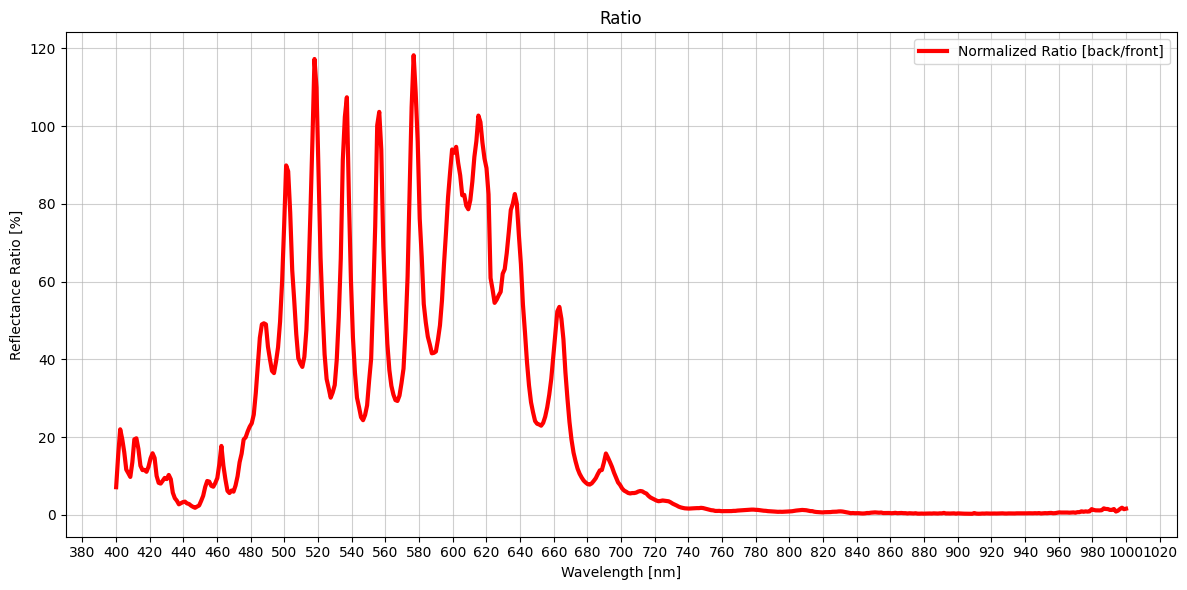

In [20]:

# 4. Plotting
norm_ratio_pct_smoothDi1 = (norm_ratio_pct_smoothDib/norm_ratio_pct_smoothDif)
#norm_ratio_pct_smoothDi2 = (norm_ratio_pct_smoothDif/norm_ratio_pct_smoothDib)
plt.figure(figsize=(12, 6))
#ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.plot(range_x, norm_ratio_pct_smoothDi1 , lw=3, color='r', label='Normalized Ratio [back/front]')
#plt.plot(range_x, norm_ratio_pct_smoothDi2 , lw=3, color='r', label='Normalized Ratio [')
#plt.ylim(0, 105)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Ratio')
plt.grid(True, alpha=.6)
plt.legend()
plt.tight_layout()
plt.savefig('Dielectric_bf.png')
# Display the table
print(df_step.to_string(index=False))

# flip

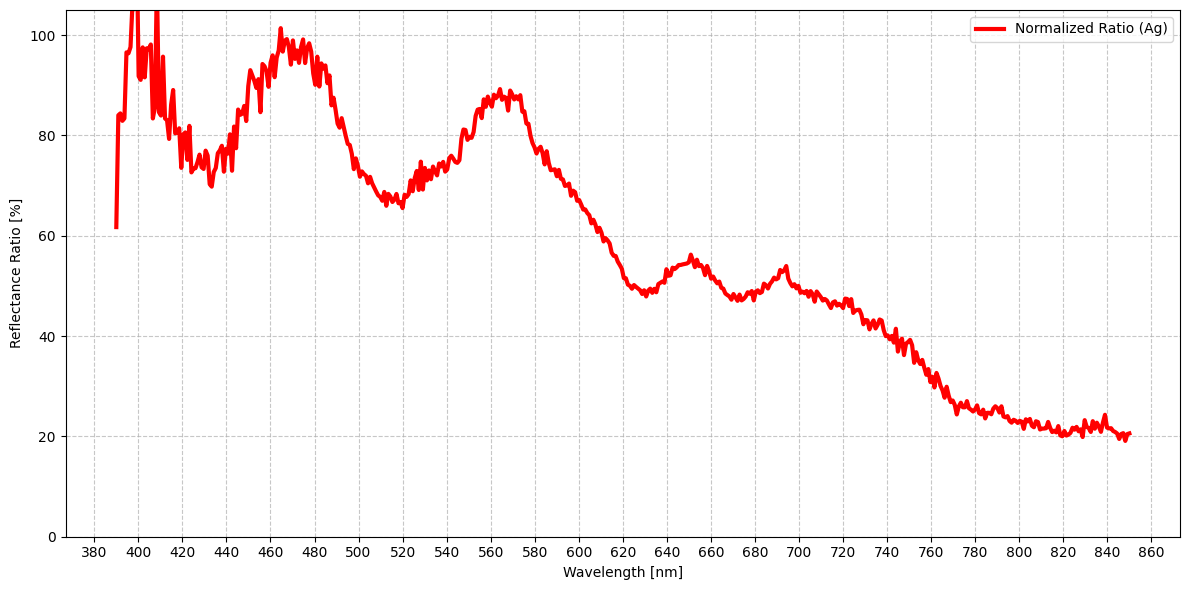

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
          390.00     1.8151            0.5144                 51.44
          409.17     2.4903            0.7057                 70.57
          428.33     2.3320            0.6609                 66.09
          447.50     2.4737            0.7010                 70.10
          466.67     2.9274            0.8296                 82.96
          485.83     2.6524            0.7517                 75.17
          505.00     2.1141            0.5991                 59.91
          524.17     2.0532            0.5818                 58.18
          543.33     2.2335            0.6329                 63.29
          562.50     2.5804            0.7313                 73.13
          581.67     2.2743            0.6445                 64.45
          600.83     1.9552            0.5541                 55.41
          620.00     1.5655            0.4436                 44.36
          639.17     1.5130            0.4288   

In [21]:
# 1. Data Loading - Silver Spectrum
df = pd.read_csv('Dielectric_flip.csv', sep=';', decimal=',', skiprows=1)
df11 = df.iloc[:, [0, 1]].dropna() # Sample (Wavelength, Intensity)
df12 = df.iloc[:, [2, 3]].dropna() # Reference (Wavelength, Intensity)

# --- BASELINE CORRECTION (Zero Shifting) ---
df11.iloc[:, 1] -= df11.iloc[:, 1].min()
df12.iloc[:, 1] -= df12.iloc[:, 1].min()

# 2. Interpolation onto common_x for Plotting
common_x = np.linspace(390, 850, 500)
y1_s = np.interp(common_x, df11.iloc[:, 0], df11.iloc[:, 1])
y2_s = np.interp(common_x, df12.iloc[:, 0], df12.iloc[:, 1])

# Calculate ratio (Reference / Sample) and scale to 100% MAX
# Added a small epsilon to avoid division by zero
ratio_s = y2_s / y1_s 
norm_plotd = (ratio_s / ratio_s.max()) * 100

# 3. Table generation (Fixed steps)
steps_x = np.linspace(390, 850, 25) 
y1_t = np.interp(steps_x, df11.iloc[:, 0], df11.iloc[:, 1])
y2_t = np.interp(steps_x, df12.iloc[:, 0], df12.iloc[:, 1])

# Calculate Table Ratios scaled to the plot maximum
raw_r_t = y2_t / y1_t
norm_r_t = raw_r_t / ratio_s.max() 
norm_pct_t = norm_r_t * 100

# 4. Create Results Table
df_step = pd.DataFrame({
    'Wavelength [nm]': np.round(steps_x, 2),
    'Raw Ratio': np.round(raw_r_t, 4),
    'Normalized Ratio': np.round(norm_r_t, 4),
    'Normalized Ratio [%]': np.round(norm_pct_t, 2)
})

# 5. Plotting
plt.figure(figsize=(12, 6))
# Using 'k' (black) for the Silver plot
plt.plot(common_x, norm_plotd*1.2, lw=3, color='r', label='Normalized Ratio (Ag)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.ylim(0, 105) 
#plt.xlim(400, 850)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Save BEFORE showing
plt.savefig('Diflip.png')
plt.show()

# Display the table
print(df_step.to_string(index=False))

# Silver

In [22]:
dfs= pd.read_csv('Silver.csv', sep=';', decimal=',', skiprows=1)

df9 = dfs.iloc[:, [0, 1]].dropna()
df10 = dfs.iloc[:, [2, 3]].dropna()

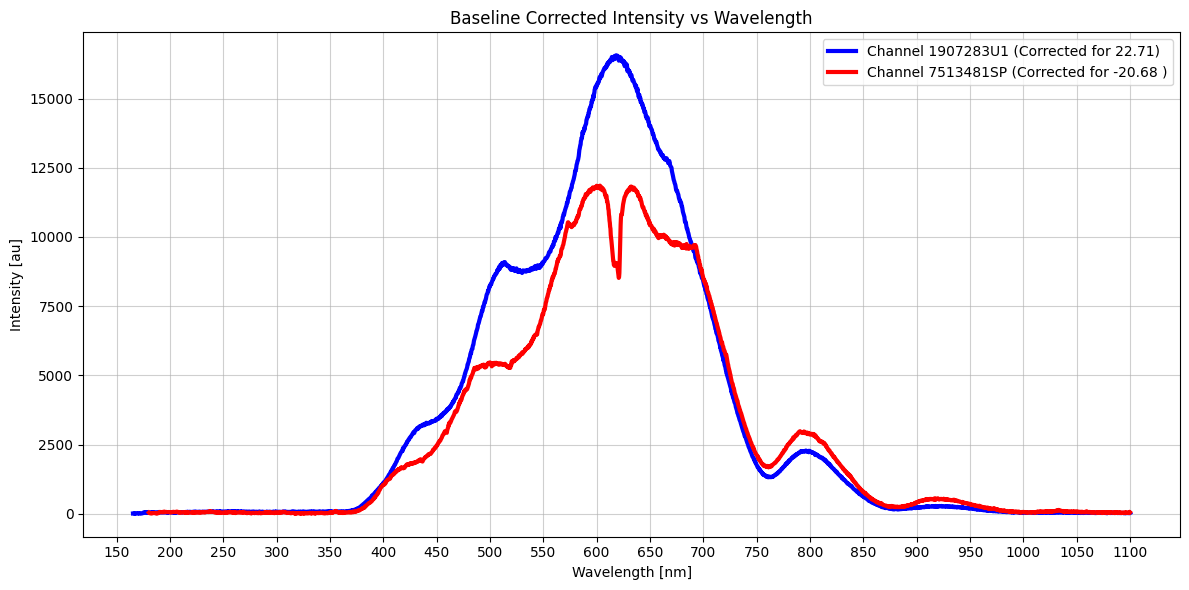

In [23]:
# Split into two dataframes
df9 = dfs.iloc[:, [0, 1]].dropna()
df10 = dfs.iloc[:, [2, 3]].dropna()

# Baseline correction: subtract the minimum value from the intensity column
df9.iloc[:, 1] -= df9.iloc[:, 1].min()
df10.iloc[:, 1] -= df10.iloc[:, 1].min()

# Plotting the corrected data
fig, ax = plt.subplots(figsize=(12, 6))
# Plotting the corrected data
#plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
plt.plot(df9.iloc[:, 0], df9.iloc[:, 1], lw=3, color='blue', label='Channel 1907283U1 (Corrected for 22.71)')
plt.plot(df10.iloc[:, 0], df10.iloc[:, 1], lw=3, color='red', label='Channel 7513481SP (Corrected for -20.68 )')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
plt.title('Baseline Corrected Intensity vs Wavelength')
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

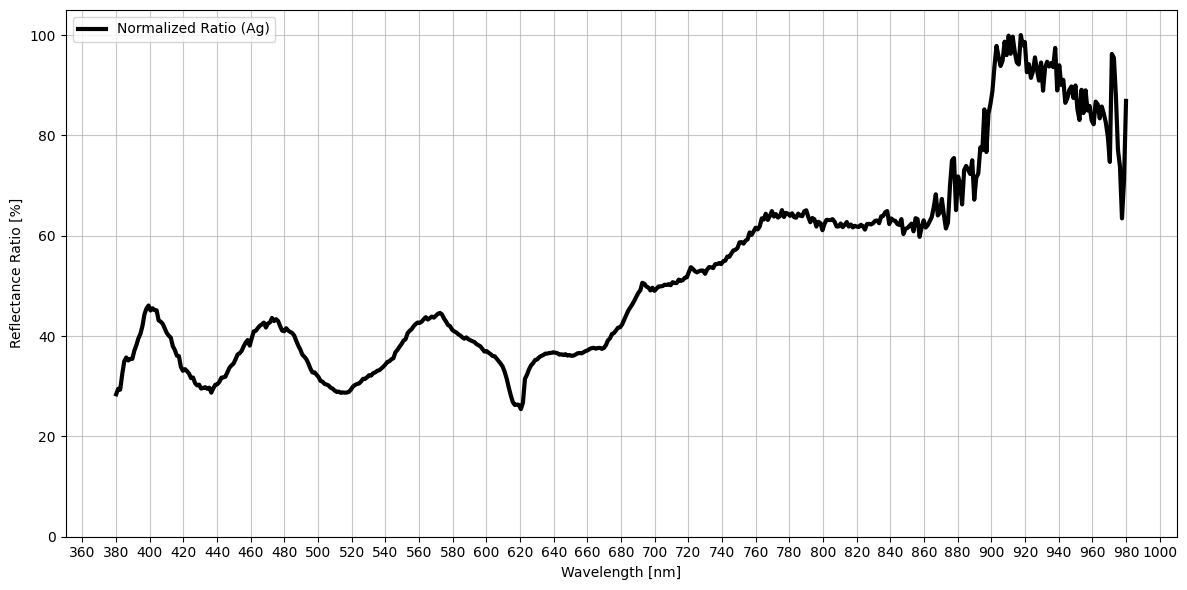

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
           380.0     0.5875            0.2839                 28.39
           405.0     0.9033            0.4365                 43.65
           430.0     0.6168            0.2981                 29.81
           455.0     0.7772            0.3756                 37.56
           480.0     0.8490            0.4103                 41.03
           505.0     0.6287            0.3038                 30.38
           530.0     0.6681            0.3228                 32.28
           555.0     0.8534            0.4124                 41.24
           580.0     0.8502            0.4108                 41.08
           605.0     0.7415            0.3583                 35.83
           630.0     0.7311            0.3533                 35.33
           655.0     0.7558            0.3652                 36.52
           680.0     0.8651            0.4180                 41.80
           705.0     1.0333            0.4993   

In [24]:
# 1. Data Loading - Updated to Gold Spectrum
df = pd.read_csv('Silver.csv', sep=';', decimal=',', skiprows=1)
df9 = df.iloc[:, [0, 1]].dropna() # Sample (Wavelength, Intensity)
df10 = df.iloc[:, [2, 3]].dropna() # Reference (Wavelength, Intensity)

# --- BASELINE CORRECTION (Zero Shifting) ---
df9.iloc[:, 1] -= df9.iloc[:, 1].min()
df10.iloc[:, 1] -= df10.iloc[:, 1].min()

# 2. Interpolation onto common_x for Plotting
common_x = np.linspace(380, 980, 500)
y1_s = np.interp(common_x, df9.iloc[:, 0], df9.iloc[:, 1])
y2_s = np.interp(common_x, df10.iloc[:, 0], df10.iloc[:, 1])

# Calculate ratio (Sample / Reference) and scale to 100% MAX
# Note: Using y1_s/y2_s as per your gold spectrum logic
ratio_s = y2_s/y1_s
norm_plots = (ratio_s / ratio_s.max()) * 100

# 3. Table generation (Fixed steps)
steps_x = np.linspace(380, 980, 25) 
y1_t = np.interp(steps_x, df9.iloc[:, 0], df9.iloc[:, 1])
y2_t = np.interp(steps_x, df10.iloc[:, 0], df10.iloc[:, 1])

# Calculate Table Ratios scaled to the plot maximum
raw_r_t =   y2_t/y1_t
norm_r_t = raw_r_t / ratio_s.max() 
norm_pct_t = norm_r_t * 100

# 4. Create Results Table
df_step = pd.DataFrame({
    'Wavelength [nm]': np.round(steps_x, 2),
    'Raw Ratio': np.round(raw_r_t, 4),
    'Normalized Ratio': np.round(norm_r_t, 4),
    'Normalized Ratio [%]': np.round(norm_pct_t, 2)
})

# 5. Plotting
plt.figure(figsize=(12, 6))
# Using 'purple' as requested for the Gold Spectrum
plt.plot(common_x, norm_plots, lw=3, color='k', label='Normalized Ratio (Ag)')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.ylim(0, 105) 
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
#plt.title('Normalized Intensity Ratio (df9 vs df10 - Baseline Corrected)')
plt.grid(True, alpha=0.7)
plt.legend()
plt.tight_layout()

# CRITICAL: Save BEFORE showing
plt.savefig('Ag18r.png')
plt.show()

# Display the table
print(df_step.to_string(index=False))

C:\Users\mdram\AppData\Local\Temp\ipykernel_15104\690879347.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


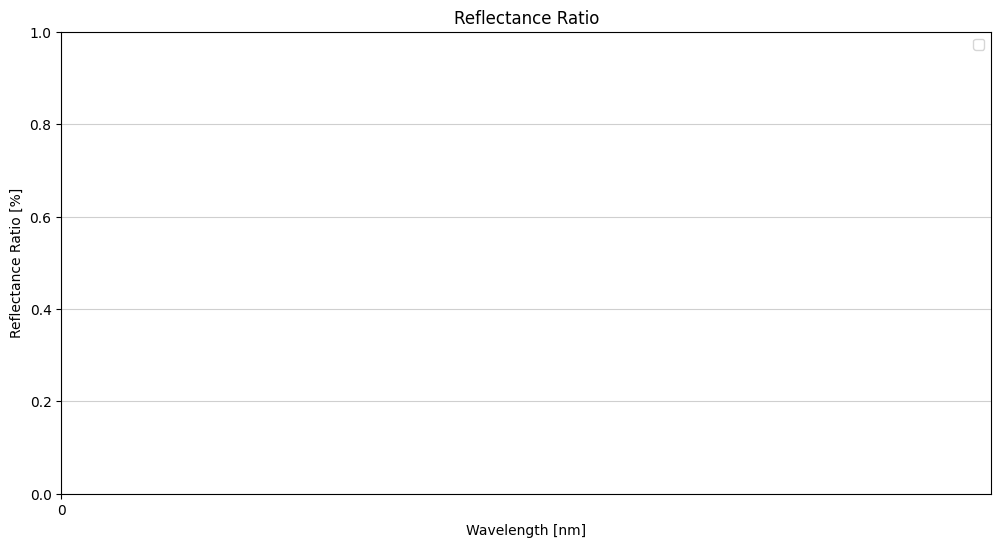

In [25]:
# 4. Plotting (Original Style)
plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.plot(range_x, norm_ratio_pct_smoothAl, lw=3, color='green', label='Normalized Ratio [%] aluminum')
#plt.plot(range_x, norm_ratio_pct_smoothAu, lw=3, color='purple', label='Normalized Ratio [%] gold')
#plt.plot(range_x, norm_ratio_pct_smoothAu/norm_ratio_pct_smoothAl, lw=3, color='purple', label='Normalized Ratio [%]ratio')
#plt.plot(range_x, norm_ratio_pct_smoothAu/norm_ratio_pct_smoothAl, lw=3, color='purple', label='Normalized Ratio [%]ratio')
#plt.plot(range_x, ratio_of_ratio_pct_Agf, lw=3, color='y', label='Normalized Ratio [%] silver')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Reflectance Ratio')
plt.grid(True, alpha=.6)
#plt.xlim(0, 1.1)
plt.legend()
#plt.savefig('ALR')
plt.show()

normalization

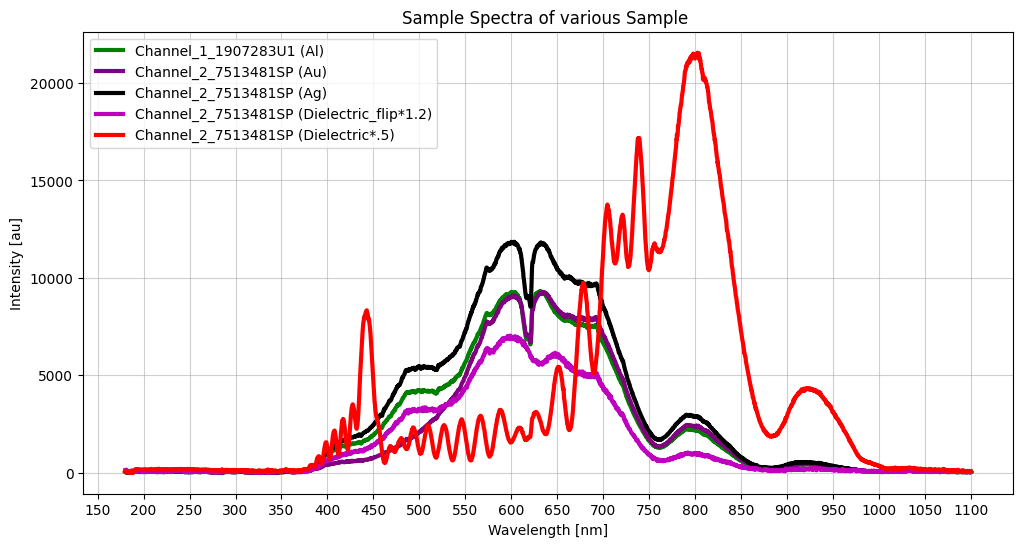

In [26]:
plt.figure( figsize=(12, 6))   #plt.figure(figsize=(12, 6), dpi=150, facecolor='#f0f0f0', edgecolor='black', linewidth=1,layout='tight')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5000))
#range_x = np.arange(390, 980)
plt.plot(df2.iloc[:,0], df2.iloc[:,1], 'g', lw=3,  label='Channel_1_1907283U1 (Al)')
plt.plot(df4.iloc[:,0], df4.iloc[:,1], 'purple', lw=3,  label='Channel_2_7513481SP (Au)')
plt.plot(df10.iloc[:,0], df10.iloc[:,1], 'k', lw=3,  label='Channel_2_7513481SP (Ag)')
plt.plot(df12.iloc[:,0], df12.iloc[:,1]*1.5, 'm', lw=3,  label='Channel_2_7513481SP (Dielectric_flip*1.2)')
plt.plot(df8.iloc[:,0], df8.iloc[:,1]*.5, 'r', lw=3,  label='Channel_2_7513481SP (Dielectric*.5)')
#plt.plot(range_x, df1/df3, lw=3, color='purple', label='Normalized Ratio [%]ratio')
#plt.xlim(620, 630) #plt.ylim(40000, 500000)
plt.title('Sample Spectra of various Sample ')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
plt.grid(True, alpha=.6)
plt.legend()
#plt.title()
plt.savefig('multi4.png')
plt.show()

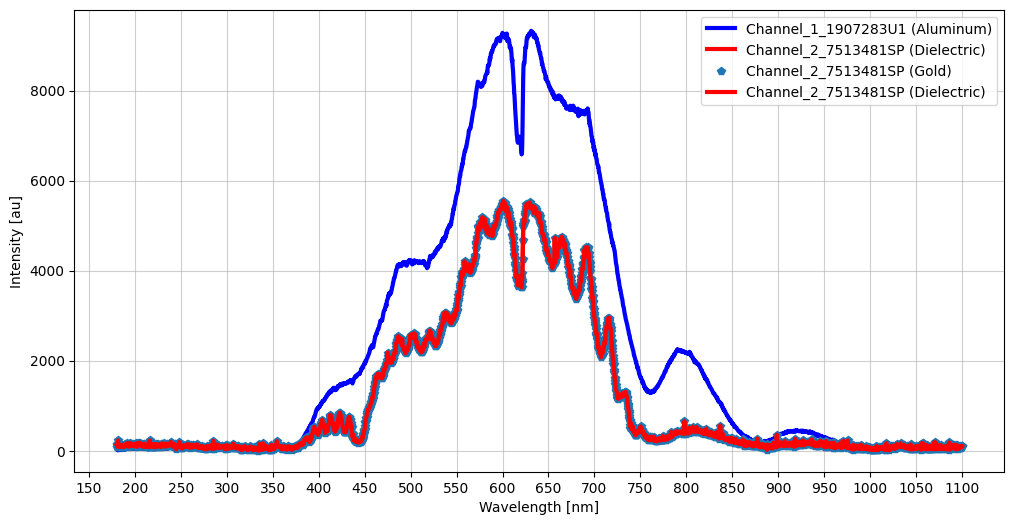

In [27]:
plt.figure( figsize=(12, 6))   #plt.figure(figsize=(12, 6), dpi=150, facecolor='#f0f0f0', edgecolor='black', linewidth=1,layout='tight')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5000))
#range_x = np.arange(390, 980)
plt.plot(df2.iloc[:,0], df2.iloc[:,1], 'b', lw=3,  label='Channel_1_1907283U1 (Aluminum)')
plt.plot(df6.iloc[:,0], df6.iloc[:,1]*1.2, 'r', lw=3,  label='Channel_2_7513481SP (Dielectric)')
plt.plot(df6.iloc[:,0], df6.iloc[:,1]*1.2, 'p', lw=3,  label='Channel_2_7513481SP (Gold)')
plt.plot(df6.iloc[:,0], df6.iloc[:,1]*1.2, 'r', lw=3,  label='Channel_2_7513481SP (Dielectric)')
#plt.plot(range_x, df1/df3, lw=3, color='purple', label='Normalized Ratio [%]ratio')
#plt.xlim(620, 630) #plt.ylim(40000, 500000)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
plt.grid(True, alpha=.6)
plt.legend()
#plt.title()
plt.savefig('Alu1')
plt.show()

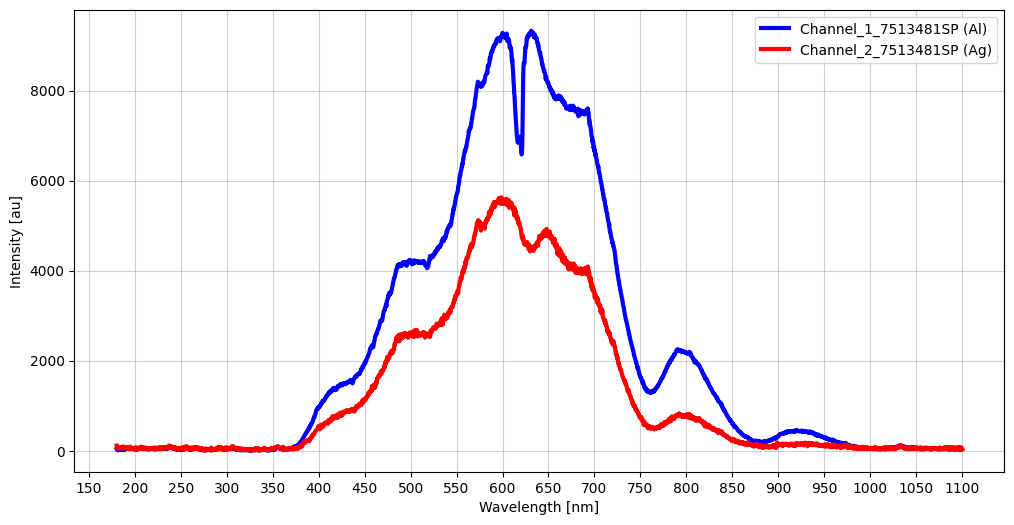

In [28]:
plt.figure( figsize=(12, 6))   #plt.figure(figsize=(12, 6), dpi=150, facecolor='#f0f0f0', edgecolor='black', linewidth=1,layout='tight')
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5000))
#range_x = np.arange(390, 980)
plt.plot(df2.iloc[:,0], df2.iloc[:,1], 'b', lw=3,  label='Channel_1_7513481SP (Al)')
plt.plot(df12.iloc[:,0], df12.iloc[:,1]*1.2, 'r', lw=3,  label='Channel_2_7513481SP (Ag)')
#plt.plot(range_x, df1/df3, lw=3, color='purple', label='Normalized Ratio [%]ratio')
#plt.xlim(620, 630) #plt.ylim(40000, 500000)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Intensity [au]')
plt.grid(True, alpha=.6)
plt.legend()
#plt.title()
#plt.savefig('Alu1')
plt.show()

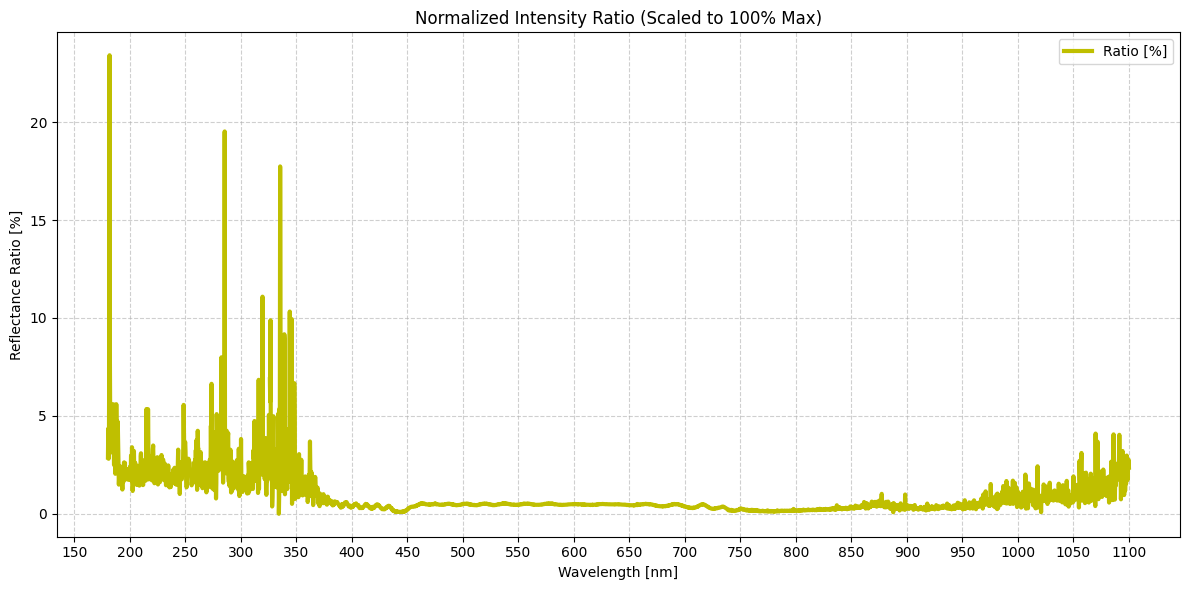

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Normalized Ratio [%]
           380.0     0.5875            0.2839                 28.39
           405.0     0.9033            0.4365                 43.65
           430.0     0.6168            0.2981                 29.81
           455.0     0.7772            0.3756                 37.56
           480.0     0.8490            0.4103                 41.03
           505.0     0.6287            0.3038                 30.38
           530.0     0.6681            0.3228                 32.28
           555.0     0.8534            0.4124                 41.24
           580.0     0.8502            0.4108                 41.08
           605.0     0.7415            0.3583                 35.83
           630.0     0.7311            0.3533                 35.33
           655.0     0.7558            0.3652                 36.52
           680.0     0.8651            0.4180                 41.80
           705.0     1.0333            0.4993   

In [29]:
# 3. 30 nm steps for the Table
range_x = (df2.iloc[:, 0])


#diel- 5,6,front_7 8. flip-13,14 si-9,10
#raw_ratio_step =  df4.iloc[:, 1]/ df2.iloc[:, 1] #Au
#raw_ratio_step =  df14.iloc[:, 1]/ df2.iloc[:, 1] #Ag
raw_ratio_step =  df6.iloc[:, 1]/ df2.iloc[:, 1] #Dielectric

# 4. Plotting (Updated for 100 Scale)
plt.figure(figsize=(12, 6))
plt.plot(range_x, raw_ratio_step, lw=3, color='y', label='Ratio [%]')
# Formatting
#plt.ylim(0, 105) # Set limit to 105% to see the 100% peak clearly
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.xlim(380, 850)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Normalized Intensity Ratio (Scaled to 100% Max)')
plt.grid(True, alpha=.6, linestyle='--')
plt.legend()

plt.tight_layout()
#plt.savefig('ALR_100Scale.png')
plt.show()

# Display the table
print(df_step.to_string(index=False))

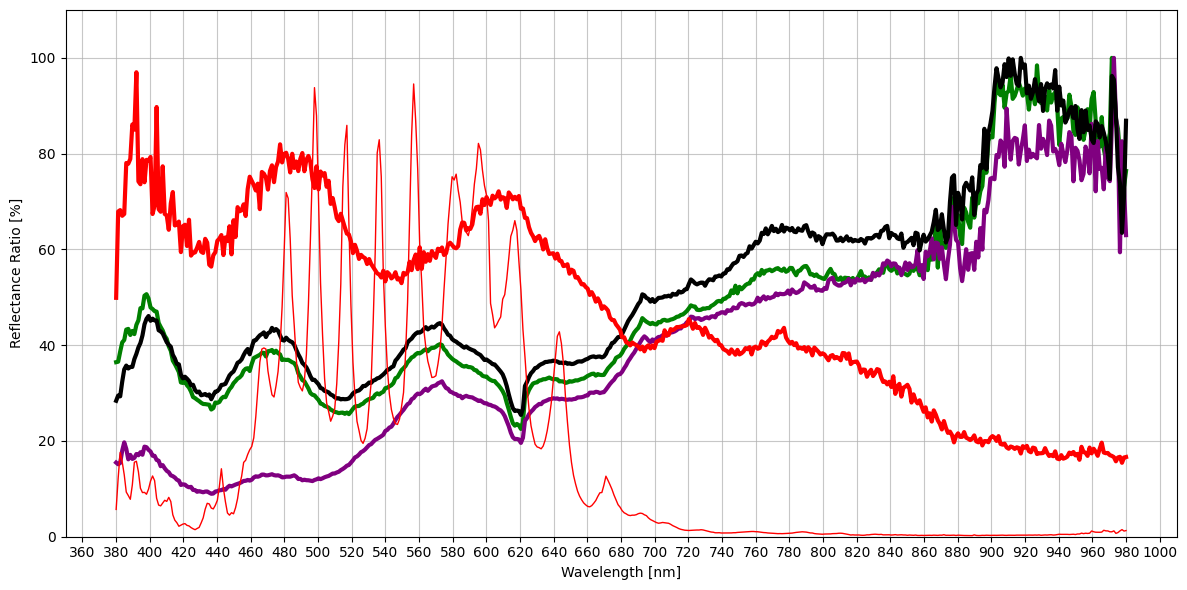

In [30]:
range_x= np.linspace(380, 980, 500)
#Au_3,4 diel- 5,6,front_7 8. flip-13,14 si-9,10
raw_ratio_step1 =  df4.iloc[:, 1]/ df2.iloc[:, 1] #Au
raw_ratio_step2 =  df10.iloc[:, 1]/ df2.iloc[:, 1] #Ag
raw_ratio_step3 =  .05*df12.iloc[:, 1]/ df2.iloc[:, 1] #Dielectric flip
raw_ratio_step3_1 = .05* df8.iloc[:, 1]/ df2.iloc[:, 1] #Dielectric_front  norm_plotd*1.2  norm_ratio_pct_smoothDi2
r1= (norm_plotd)*.97
r2 = (norm_ratio_pct_smoothDi1)*.8
plt.figure(figsize=(12, 6))
plt.ylim(0, 110)
plt.plot(range_x, norm_plota, lw=3, color='g', label= 'Al')
plt.plot(range_x, norm_plotg, lw=3, color='purple', label= 'Au')
plt.plot(range_x, norm_plots, lw=3, color='k', label= 'Ag')
plt.plot(range_x, r1, lw=3, color='r', label='Dielectric_(flip)')
plt.plot(range_x, r2, lw=1, color='r', label='Dielectric')
#plt.plot(range_x, raw_ratio_step2, lw=2, color='g', label='Ratio_Ag Respect to Al') #flip
#plt.plot(range_x, raw_ratio_step2, lw=2, color='k', label='Ratio_Ag Respect to Al')
#plt.plot(range_x, raw_ratio_step3, lw=1, color='r', label='Ratio_Dielectric Respect to Al')
#plt.plot(range_x, raw_ratio_step3_1, lw=1, color='y', label='Ratio_Dielectric Respect to Al') #front
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
#plt.xlim(350, 450)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
#plt.title('Ratio (Scaled to 100%)')
plt.grid(True, alpha=.7)
plt.legend
plt.savefig('combine.png')
plt.tight_layout()
plt.show()
#print(df_step.to_string(index=False))

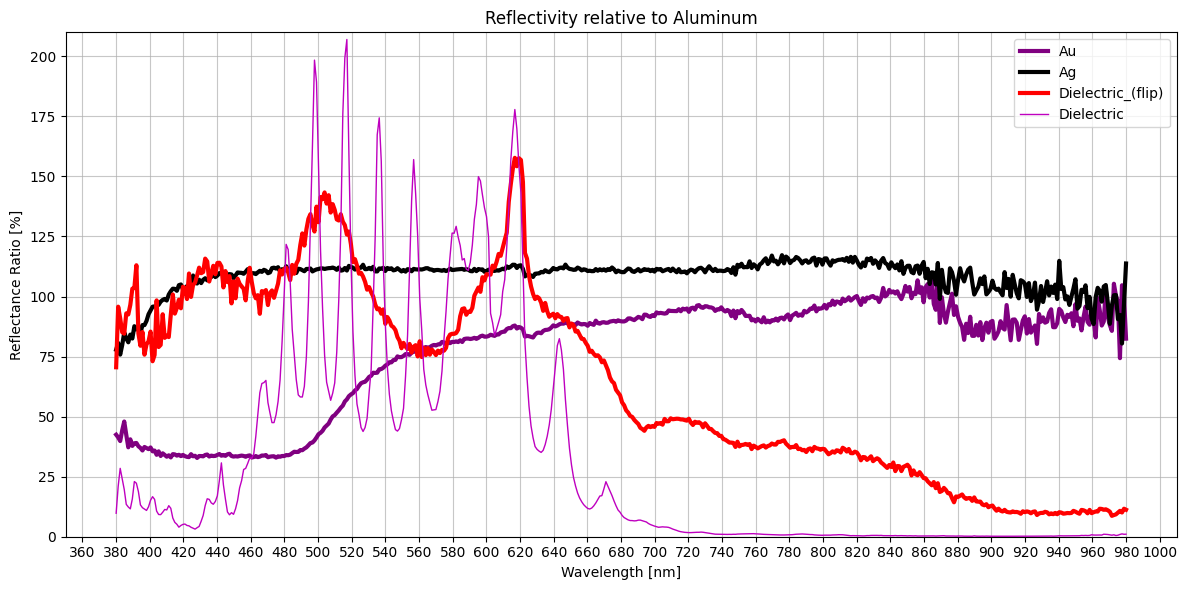

In [31]:
range_x= np.linspace(380, 980, 500)
#Au_3,4 diel- 5,6,front_7 8. flip-13,14 si-9,10
#raw_ratio_step1 =  (df4.iloc[:, 1]/ df2.iloc[:, 1])  #Au
#raw_ratio_step2 =  df10.iloc[:, 1]/ df2.iloc[:, 1] #Ag
#raw_ratio_step3 =  .05*df12.iloc[:, 1]/ df2.iloc[:, 1] #Dielectric flip
#raw_ratio_step3_1 = .05* df8.iloc[:, 1]/ df2.iloc[:, 1] #Dielectric_front  norm_plotd*1.2  norm_ratio_pct_smoothDi2
#aluminum
r1= (norm_plotd*.5 /norm_plota) *100
r2 = (norm_ratio_pct_smoothDi1*.5/norm_plota) *100
au= (norm_plotg/norm_plota)*100
ag= (norm_plots/norm_plota )*100

#gold
r3= (norm_plotd*.5 /norm_plotg) *100
r4 = (norm_ratio_pct_smoothDi1*.5/norm_plotg) *100
ag1= (norm_plota/norm_plotg)*100
al1= (norm_plots/norm_plotg )*100

plt.figure(figsize=(12, 6))
plt.ylim(0, 300)
#plt.plot(range_x, norm_plota, lw=3, color='g', label= 'Al')
plt.plot(range_x, au, lw=3, color='purple', label= 'Au')
plt.plot(range_x, ag, lw=3, color='k', label= 'Ag')
plt.plot(range_x, r1, lw=3, color='r', label='Dielectric_(flip)')
plt.plot(range_x, r2, lw=1, color='m', label='Dielectric')
#plt.plot(range_x, raw_ratio_step2, lw=2, color='g', label='Ratio_Ag Respect to Al') #flip
#plt.plot(range_x, raw_ratio_step2, lw=2, color='k', label='Ratio_Ag Respect to Al')
#plt.plot(range_x, raw_ratio_step3, lw=1, color='r', label='Ratio_Dielectric Respect to Al')
#plt.plot(range_x, raw_ratio_step3_1, lw=1, color='y', label='Ratio_Dielectric Respect to Al') #front
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.ylim(0, 210)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Reflectivity relative to Aluminum')
plt.grid(True, alpha=.7)
plt.legend()
plt.savefig('combine1.png')
plt.tight_layout()
plt.show()
#print(df_step.to_string(index=False))

In [34]:
# aluminum

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Ratio [%]
        380.0000     0.4248            0.4248    42.4804
        404.0481     0.3411            0.3411    34.1093
        429.2986     0.3360            0.3360    33.6012
        454.5491     0.3378            0.3378    33.7790
        479.7996     0.3358            0.3358    33.5798
        503.8477     0.4548            0.4548    45.4759
        529.0982     0.6544            0.6544    65.4375
        554.3487     0.7572            0.7572    75.7230
        579.5992     0.8113            0.8113    81.1273
        604.8497     0.8362            0.8362    83.6204
        628.8978     0.8418            0.8418    84.1812
        654.1483     0.8919            0.8919    89.1852
        679.3988     0.8976            0.8976    89.7635
        704.6493     0.9304            0.9304    93.0414
        729.8998     0.9598            0.9598    95.9772
        753.9479     0.9192            0.9192    91.9179
        779.1984     0.9254    

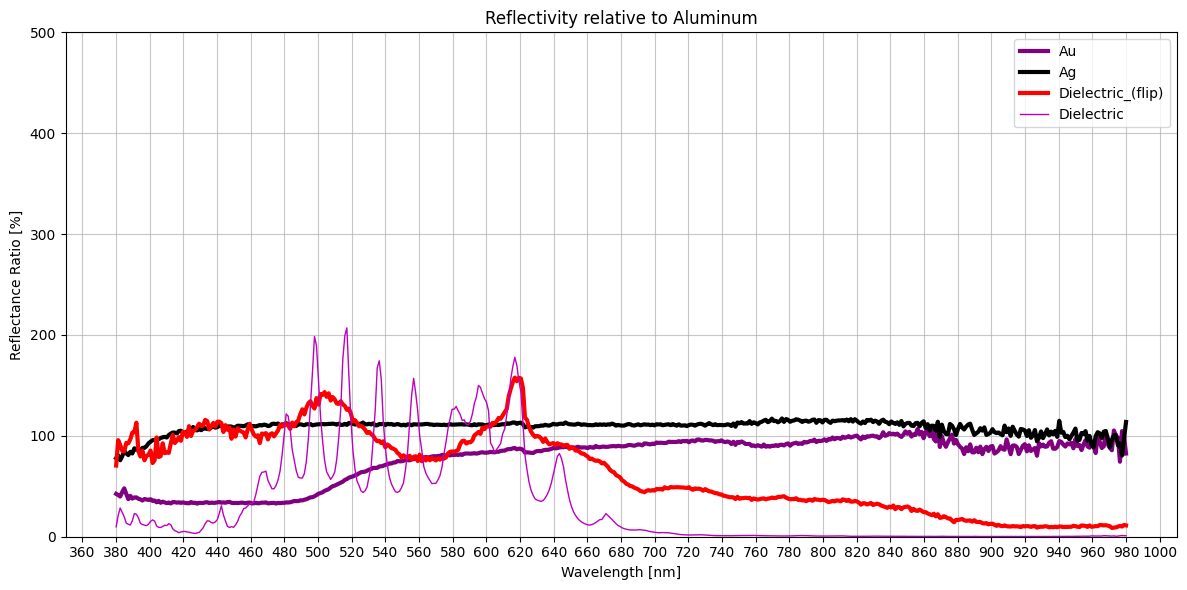

In [33]:
range_x = np.linspace(380, 980, 500)

# ... (Previous calculation logic for au, ag, r1, r2, etc. remains same) ...

# 1. NEW: Create Dataframe for Table Printing
# We will use a subset of points (e.g., every 40th point) for the table display
indices = np.linspace(0, len(range_x) - 1, 25, dtype=int) 

df_summary = pd.DataFrame({
    'Wavelength [nm]': range_x[indices],
    'Raw Ratio': (au[indices] / 100), # Assuming 'au' was already scaled by 100
    'Normalized Ratio': (au[indices] / 100), # Adjust logic if norm_plota scaling differs
    'Ratio [%]': au[indices]
}).round(4)

# Print the table as requested
#print("\n--- Reflectivity Analysis Table (Au Sample) ---")
print(df_summary.to_string(index=False))

# 2. Plotting Code
plt.figure(figsize=(12, 6))
plt.ylim(0, 500)
plt.plot(range_x, au, lw=3, color='purple', label= 'Au')
plt.plot(range_x, ag, lw=3, color='k', label= 'Ag')
plt.plot(range_x, r1, lw=3, color='r', label='Dielectric_(flip)')
plt.plot(range_x, r2, lw=1, color='m', label='Dielectric')

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Reflectivity relative to Aluminum')
plt.grid(True, alpha=.7)
plt.legend()
plt.tight_layout()
plt.savefig('combine2.png')
plt.show()

 Wavelength [nm]  Raw Ratio  Normalized Ratio  Ratio [%]
        380.0000     0.4248            0.4248    42.4804
        404.0481     0.3411            0.3411    34.1093
        429.2986     0.3360            0.3360    33.6012
        454.5491     0.3378            0.3378    33.7790
        479.7996     0.3358            0.3358    33.5798
        503.8477     0.4548            0.4548    45.4759
        529.0982     0.6544            0.6544    65.4375
        554.3487     0.7572            0.7572    75.7230
        579.5992     0.8113            0.8113    81.1273
        604.8497     0.8362            0.8362    83.6204
        628.8978     0.8418            0.8418    84.1812
        654.1483     0.8919            0.8919    89.1852
        679.3988     0.8976            0.8976    89.7635
        704.6493     0.9304            0.9304    93.0414
        729.8998     0.9598            0.9598    95.9772
        753.9479     0.9192            0.9192    91.9179
        779.1984     0.9254    

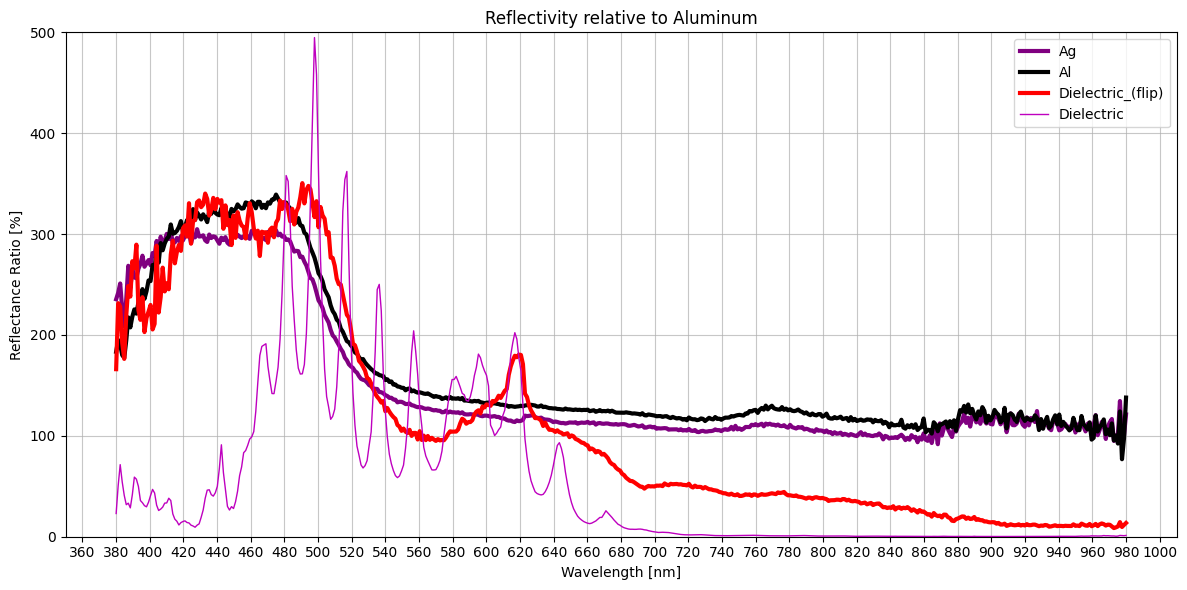

In [32]:
range_x = np.linspace(380, 980, 500)

# ... (Previous calculation logic for au, ag, r1, r2, etc. remains same) ...

# 1. NEW: Create Dataframe for Table Printing
# We will use a subset of points (e.g., every 40th point) for the table display
indices = np.linspace(0, len(range_x) - 1, 25, dtype=int) 

df_summary = pd.DataFrame({
    'Wavelength [nm]': range_x[indices],
    'Raw Ratio': (au[indices] / 100), # Assuming 'au' was already scaled by 100
    'Normalized Ratio': (au[indices] / 100), # Adjust logic if norm_plota scaling differs
    'Ratio [%]': au[indices]
}).round(4)

# Print the table as requested
#print("\n--- Reflectivity Analysis Table (Au Sample) ---")
print(df_summary.to_string(index=False))

# 2. Plotting Code
plt.figure(figsize=(12, 6))
plt.ylim(0, 500)
plt.plot(range_x, ag1, lw=3, color='purple', label= 'Ag')
plt.plot(range_x, al1, lw=3, color='k', label= 'Al')
plt.plot(range_x, r3, lw=3, color='r', label='Dielectric_(flip)')
plt.plot(range_x, r4, lw=1, color='m', label='Dielectric')

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(20))
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Reflectivity relative to Aluminum')
plt.grid(True, alpha=.7)
plt.legend()
plt.tight_layout()
plt.savefig('combine2.png')
plt.show()

range_x = (df2.iloc[:, 0])
range_x= np.linspace(380, 980, 500)



#Au_3,4 diel- 5,6,front_7 8. flip-13,14 si-9,10
raw_ratio_step1 =  df4.iloc[:, 1]/ df2.iloc[:, 1] #Au
raw_ratio_step2_1 =  df10.iloc[:, 1]/ df2.iloc[:, 1] #Ag
raw_ratio_step3 =  .05*df6.iloc[:, 1]/ df2.iloc[:, 1] #Dielectric
raw_ratio_step3_1 = .05* df12..iloc[:, 1]/ df2.iloc[:, 1] #Dielectric_front

plt.figure(figsize=(12, 6))
plt.ylim(0, .5)
plt.plot(range_x, raw_ratio_step1, lw=3, color='purple', label='Ratio_Au Respect to Al')
#plt.plot(range_x, raw_ratio_step2, lw=2, color='g', label='Ratio_Ag Respect to Al') #flip
plt.plot(range_x, raw_ratio_step2_1, lw=2, color='k', label='Ratio_Ag Respect to Al')
plt.plot(range_x, raw_ratio_step3, lw=1, color='r', label='Ratio_Dielectric Respect to Al')
plt.plot(range_x, raw_ratio_step3_1, lw=1, color='y', label='Ratio_Dielectric Respect to Al') #front
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(50))
#plt.xlim(350, 450)
plt.xlabel('Wavelength [nm]')
plt.ylabel('Reflectance Ratio [%]')
plt.title('Ratio (Scaled to 100%)')
plt.grid(True, alpha=.7)
plt.legend()
plt.tight_layout()
plt.show()
#print(df_step.to_string(index=False))